# The subsurface thermal regime: where is the heat, and is the source rock cooking?

*Module: Tectonics & ancient Earth — basin thermal history, with calibrated uncertainty.*

Temperature at depth is the hinge of two multi-billion-dollar exploration decisions. **Geothermal:** a power
project needs rock hotter than ~150 °C within drillable depth — so *where is the heat?* **Petroleum:** a source
rock generates oil only in a temperature window (the "oil window", roughly 100–150 °C); too cool and nothing is
charged, too hot and it is all gas or dead carbon — so *did the source rock cook, and when, relative to the
trap?* Both reduce to inferring the Earth's **thermal field** from sparse, noisy point measurements, and then
asking a yes/no question of it **with honest uncertainty**.

We use **real data**: the **IHFC Global Heat Flow Database, Release 2024** — every published heat-flow
determination on Earth. We take the ~5,000 onshore-continental wells of the western United States, the
Cordilleran geothermal belt, each carrying the three quantities Fourier's law ties together: the temperature
gradient, the thermal conductivity, and the surface heat flow.

The notebook has a spine and a warning. The spine: heat-flow data → a thermal field → the geothermal and
petroleum decisions. The warning, which is the real lesson: **the obvious way to make the map produces a
beautiful, confident picture whose uncertainty is a lie** — and the only way to find that out is to validate
it. We will build the naive map, watch it fail cross-validation, diagnose *why* (the variogram), fix the
uncertainty so it is honest, and only then let it make a decision.

> Real data throughout (IHFC GHFDB 2024, CC-BY 4.0). Modelling is `mixle` (Gaussian-process field) and
> `mixle_pde` (`geotherm`, `easy_ro`). Every figure is one `_geoviz` call.

## 1. The data: a continent's heat, one dot per well

Each dot is a well where someone measured how fast temperature rises with depth and how well the rock conducts
heat. The pattern is not subtle: the **Basin and Range** and the Cascades/Cordillera run hot (thin, stretched,
magmatically active crust), while the **Colorado Plateau** and the craton to the east run cool (thick, stable
crust). That first-order pattern is the geothermal signal — and the well-to-well *scatter* on top of it is the
problem we will spend the notebook being honest about.

4149 wells | heat flow q: median 75, 10-90% 41-117 mW/m^2
each well carries: gradient (K/km), conductivity (W/m/K), heat flow q (mW/m^2)


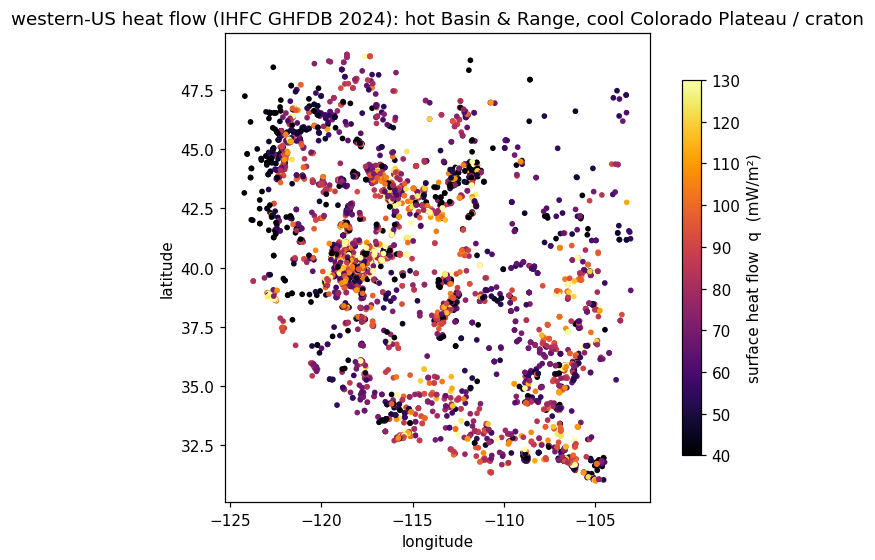

In [1]:
import numpy as np, warnings; warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
import _geodata, _geoviz as gv
plt.rcParams.update({'figure.dpi': 110})

h = _geodata.load_heat_flow(region='west')          # real IHFC GHFDB 2024 wells, western US
print('%d wells | heat flow q: median %.0f, 10-90%% %.0f-%.0f mW/m^2'
      % (len(h.df), np.median(h.q), np.percentile(h.q,10), np.percentile(h.q,90)))
print('each well carries: gradient (K/km), conductivity (W/m/K), heat flow q (mW/m^2)')
gv.geoscatter(h.lon, h.lat, np.clip(h.q,40,130), clabel='surface heat flow  q  (mW/m²)',
              title='western-US heat flow (IHFC GHFDB 2024): hot Basin & Range, cool Colorado Plateau / craton');

## 2. The physics: from heat flow to temperature at depth, and to maturity

Conductive heat transport obeys **Fourier's law**: the heat flux is $q = k\,\frac{dT}{dz}$, where $k$ is
thermal conductivity. Three consequences we will use:

1. **The closure.** Heat flow, gradient, and conductivity are not independent — $q = k\cdot(dT/dz)$ *defines*
   one from the other two. The database stores all three; the closure holds almost exactly (we check it below),
   which is reassuring but partly **circular**: in many wells $q$ was *computed* from gradient × conductivity,
   not measured independently. So the closure validates bookkeeping, not geology.
2. **The geotherm.** Integrating Fourier's law down a layered column gives temperature with depth,
   $T(z) = T_0 + \int_0^z q/k\,dz'$, bent concave by radiogenic heat production. This is
   `mixle_pde.geotherm`, and it turns a heat flow into the **temperature at a target depth** — the
   geothermal observable.
3. **Maturity.** Hold organic matter at temperature through geological time and it matures irreversibly. The
   **EASY%Ro** model (Sweeney & Burnham 1990) — twenty parallel Arrhenius reactions integrated over the
   time–temperature history — converts a thermal history into vitrinite reflectance %Ro, the measurable
   maturity. Oil window ≈ 0.6–1.35 %Ro. This is `mixle_pde.easy_ro` (validated against its published
   calibration in the package tests).

In [2]:
from mixle_pde import geotherm, easy_ro

# (1) check the Fourier closure on the real data
pred_q = h.df.T_grad/1000.0 * h.df.tc * 1000.0      # (K/km)->(K/m) * (W/m/K) -> W/m^2 -> mW/m^2
print('Fourier closure q = k·(dT/dz):  correlation %.3f, median |residual| %.1f mW/m^2 (near-definitional)'
      % (np.corrcoef(h.q, pred_q)[0,1], np.median(np.abs(h.q-pred_q))))

# (2) geotherm: temperature at 4 km for a cool vs a hot well (k=2.5, surface 12C)
for q in (55, 95):
    z, T = geotherm(np.full(40,100.), conductivity=2.5, surface_temp=12., surface_heat_flow=q/1000.)
    print('  q=%3d mW/m^2  ->  T(4 km) = %3.0f C  (gradient %.0f C/km)' % (q, T[-1], (T[-1]-12)/4))

# (3) maturity: a horizon buried to 4 km over 60 Myr at a hot vs cool geotherm
def burial_ro(q_mwm2, final_depth=4000., t_total=60., k=2.5, surf=12., n=300):
    t = np.linspace(0, t_total, n); depth = final_depth*(t/t_total)            # linear subsidence
    grad = (q_mwm2/1000.)/k*1000.                                              # C/km
    T = surf + grad*depth/1000.
    return easy_ro(t, T)
print('  maturity of a 4 km horizon (60 Myr burial):  cool q=55 -> %.2f %%Ro,  hot q=95 -> %.2f %%Ro'
      % (burial_ro(55), burial_ro(95)))

Fourier closure q = k·(dT/dz):  correlation 0.966, median |residual| 0.7 mW/m^2 (near-definitional)
  q= 55 mW/m^2  ->  T(4 km) = 100 C  (gradient 22 C/km)
  q= 95 mW/m^2  ->  T(4 km) = 164 C  (gradient 38 C/km)
  maturity of a 4 km horizon (60 Myr burial):  cool q=55 -> 0.59 %Ro,  hot q=95 -> 1.24 %Ro


## 3. The obvious map — and why you must not trust it

The standard move is to interpolate the scattered heat-flow points into a smooth field with a **Gaussian
process** (kriging), read off temperature at depth, and draw the geothermal fairway. It produces a gorgeous,
authoritative map with tight uncertainty bands. Before believing a single pixel, we **hold out 20 % of the
wells**, predict them from the rest, and check two things: are the predictions accurate, and do the 95 %
intervals actually contain the truth 95 % of the time?

naive GP  (lengthscale 0.20):
  held-out RMSE 27.4 mW/m^2   vs   just-predict-the-mean 28.5 mW/m^2   -> almost no skill
  95% interval coverage 0.36  (should be 0.95)  -> the map is badly OVER-confident


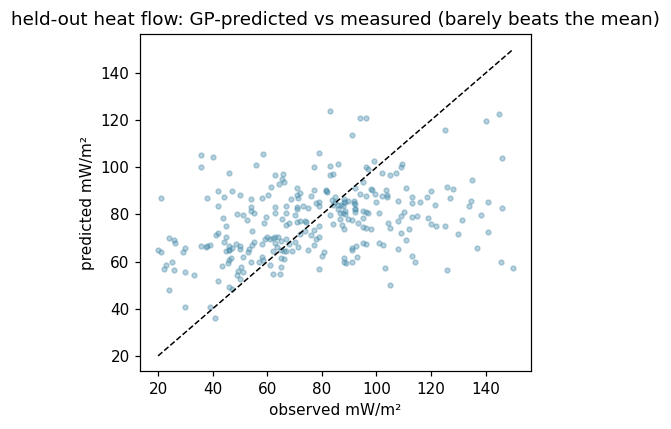

In [3]:
from mixle.models import GaussianProcessRegressor

rng = np.random.RandomState(1)
w = h.df.iloc[rng.permutation(len(h.df))[:1400]].reset_index(drop=True)        # subsample for an exact GP
X = np.c_[w.lon, w.lat]; y = w.q.to_numpy(float); Xs = (X-X.mean(0))/X.std(0); ym = y.mean()
idx = rng.permutation(len(w)); te, tr = idx[:len(w)//5], idx[len(w)//5:]
Xtr, ytr, Xte, yte = Xs[tr], y[tr]-ym, Xs[te], y[te]

# --- MODEL: smooth GP interpolation, hyperparameters by marginal likelihood ---
best = max(((GaussianProcessRegressor(lengthscale=ls, noise=nz, amplitude=y.std())
             .log_marginal_likelihood(Xtr, ytr), ls, nz)
            for ls in (0.2,0.35,0.5,0.8) for nz in (6.,10.,16.)), key=lambda t: t[0])
ls, nz = best[1], best[2]
gp = GaussianProcessRegressor(lengthscale=ls, noise=nz, amplitude=y.std())
mu, cov = gp.predict(Xtr, ytr, Xte, return_cov=True); mu = mu + ym
sd_naive = np.sqrt(np.diag(cov))                                               # GP's own (latent) uncertainty
rmse = np.sqrt(np.mean((yte-mu)**2)); cover = np.mean(np.abs((yte-mu)/sd_naive) < 1.96)
print('naive GP  (lengthscale %.2f):' % ls)
print('  held-out RMSE %.1f mW/m^2   vs   just-predict-the-mean %.1f mW/m^2   -> almost no skill'
      % (rmse, y.std()))
print('  95%% interval coverage %.2f  (should be 0.95)  -> the map is badly OVER-confident'
      % cover)
gv.fit_scatter(yte, mu, units='mW/m²', title='held-out heat flow: GP-predicted vs measured (barely beats the mean)');

The map is a lie in two ways at once. Its predictions barely beat *ignoring location and quoting the regional
average* (RMSE ≈ the data's own spread), and its 95 % intervals contain the truth far less than 95 % of the
time. A decision made on this map — "drill here, the model says 175 ± 8 °C" — would be unsupported by the data
it was built from. **Why** is the question that turns a plot into understanding.

## 4. Diagnosis: the variogram, and the 96 % nugget

The diagnostic for interpolability is the **variogram**: the average squared difference between pairs of wells,
$\gamma(h)=\tfrac12\,\overline{(q_i-q_j)^2}$, as a function of their separation $h$. If nearby wells are alike,
$\gamma$ is small at short range and climbs to the total variance (the **sill**) at long range — that rising
part is the *spatially structured*, interpolable signal. The value $\gamma$ extrapolates to at **zero**
separation is the **nugget**: variance that is already present between co-located wells, and is therefore
*unpredictable* from location. For western-US heat flow the nugget is essentially the entire sill.

nugget 782  is  96% of the sill (total variance 814)  -> almost nothing is spatially structured


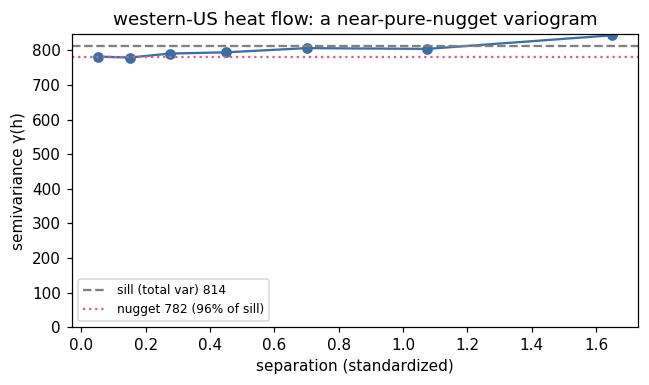

In [4]:
import scipy.spatial as sp
D = sp.distance_matrix(Xs, Xs); diff2 = (y[None,:]-y[:,None])**2
edges = [0,0.1,0.2,0.35,0.55,0.85,1.3,2.0]; lag, semi = [], []
for lo, hi in zip(edges[:-1], edges[1:]):
    m = (D>lo)&(D<=hi); lag.append((lo+hi)/2); semi.append(0.5*diff2[m].mean())
nugget, sill = semi[0], y.var()
print('nugget %.0f  is  %.0f%% of the sill (total variance %.0f)  -> almost nothing is spatially structured'
      % (nugget, 100*nugget/sill, sill))
gv.variogram(lag, semi, sill=sill, nugget=nugget,
             title='western-US heat flow: a near-pure-nugget variogram', xlabel='separation (standardized)');

**96 % nugget.** Two wells a few kilometres apart disagree almost as much as two wells across the whole region.
Three real causes: **measurement variance** (BHT corrections, drilling disturbance, differing methods across a
century of compilation); **groundwater advection**, which moves heat sideways and breaks the purely conductive
picture our geotherm assumes; and genuine **short-scale geology** (faults, intrusions, conductivity contrasts).
Whatever the mix, the consequence is unavoidable: *you cannot predict one well's heat flow from its neighbours*,
and any map that claims to is hiding the nugget inside falsely-tight error bars.

## 5. Honest uncertainty, and what is actually predictable

Two moves. **First**, the predictive interval for a *new well* must at least include the nugget (observation
variance), not only the GP's latent-function uncertainty. That recovers much of the lost coverage (95 %
interval: 0.36 → 0.80) — but the calibration curve below shows it is *still* over-confident at **every** level:
the nugget is not even Gaussian, and no honest bookkeeping makes one well's heat flow predictable when 96 % of
the variance is nugget. **Second**, and decisively: predict only what survives **aggregation**. Average the
wells in a cell and the nugget falls as $1/\sqrt{n}$; the central-limit theorem makes the cell mean Gaussian and
its standard error genuinely *calibrated*, exposing the real **regional trend**. Every decision below rests on
the aggregated cells, not the per-well map.

95% coverage:  naive 0.36  ->  nugget-included 0.80

134 cells with >=8 wells: cell-mean q ranges 35-139 mW/m^2, typical SE 4.7 (nugget averaged down)
between-cell sd 15  >>  typical SE 5  -> the REGIONAL trend is real and resolvable


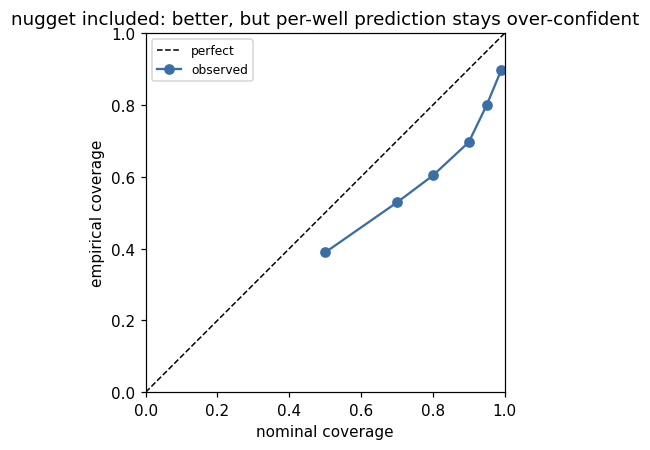

In [5]:
# (1) honest calibration: include the nugget (observation noise) in the predictive sd
sd_honest = np.sqrt(np.diag(cov) + nz**2)
levels = np.array([0.5,0.7,0.8,0.9,0.95,0.99]); zthr = {0.5:0.674,0.7:1.036,0.8:1.282,0.9:1.645,0.95:1.96,0.99:2.576}
emp_naive  = [np.mean(np.abs((yte-mu)/sd_naive)  < zthr[l]) for l in levels]
emp_honest = [np.mean(np.abs((yte-mu)/sd_honest) < zthr[l]) for l in levels]
gv.calibration(levels, emp_honest, title='nugget included: better, but per-well prediction stays over-confident')
print('95%% coverage:  naive %.2f  ->  nugget-included %.2f' % (emp_naive[4], emp_honest[4]))

# (2) aggregate to 1deg cells: the regional trend with a calibrated standard error
w2 = h.df.copy(); w2['cell'] = list(zip(np.floor(w2.lon).astype(int), np.floor(w2.lat).astype(int)))
agg = w2.groupby('cell').q.agg(['mean','std','count']); agg = agg[agg['count'] >= 8]
agg['se'] = agg['std']/np.sqrt(agg['count'])
print('\n%d cells with >=8 wells: cell-mean q ranges %.0f-%.0f mW/m^2, typical SE %.1f (nugget averaged down)'
      % (len(agg), agg['mean'].min(), agg['mean'].max(), agg['se'].median()))
print('between-cell sd %.0f  >>  typical SE %.0f  -> the REGIONAL trend is real and resolvable'
      % (agg['mean'].std(), agg['se'].median()))

## 6. Decision 1 — the geothermal fairway, with calibrated confidence

Now a defensible decision. For each well-dense cell we have a calibrated posterior on its *regional* heat flow
($\text{mean} \pm \text{SE}$). Push it through the geotherm to temperature at 4 km, and compute the probability
it clears the **150 °C** power threshold — propagating the heat-flow uncertainty, not ignoring it. The cells
that clear it are the honest fairway, and they fall in the **known high-heat-flow provinces** — the Basin and
Range and the Rio Grande rift — the external check that the *regional* signal (unlike the pointwise map) is
real. They are patchy, not a clean belt: with sparse, noisy wells even the calibrated regional inference
resolves hot *cells*, not sharp boundaries — itself an honest limit worth seeing.

cells where P(T@4km > 150C) > 0.8 (the confident geothermal fairway): 16 of 134


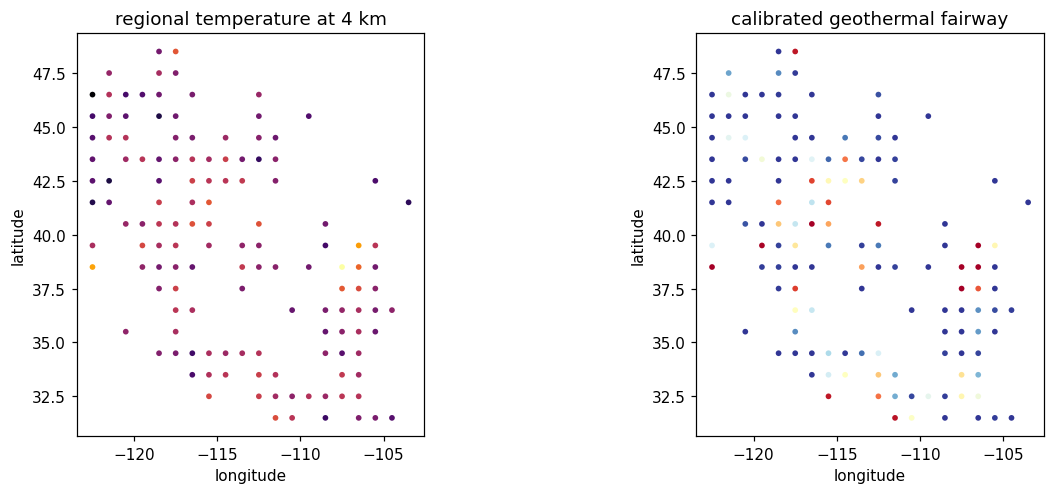

In [6]:
from mixle_pde import geotherm
def T_at_4km(q_mwm2, k=2.5, surf=12.):
    return geotherm(np.full(40,100.), conductivity=k, surface_temp=surf, surface_heat_flow=q_mwm2/1000.)[1][-1]

# --- MODEL: propagate each cell's heat-flow posterior (mean ± SE) to P(T@4km > 150C) ---
rows = []
for (lon,lat), r in agg.iterrows():
    Tmean = T_at_4km(r['mean']); Tse = abs(T_at_4km(r['mean']+r['se']) - Tmean)   # T is ~linear in q
    p_hot = np.mean(rng.normal(Tmean, Tse, 4000) > 150)
    rows.append((lon+0.5, lat+0.5, r['mean'], Tmean, p_hot))
F = np.array(rows)
print('cells where P(T@4km > 150C) > 0.8 (the confident geothermal fairway): %d of %d' % (np.sum(F[:,4]>0.8), len(F)))
fig, ax = plt.subplots(1,2, figsize=(12,4.6))
gv.geoscatter(F[:,0],F[:,1],F[:,3], clabel='T @ 4 km (°C)', cmap='inferno', title='regional temperature at 4 km', ax=ax[0])
gv.geoscatter(F[:,0],F[:,1],F[:,4], clabel='P(T@4km > 150°C)', cmap='RdYlBu_r', vmin=0, vmax=1, title='calibrated geothermal fairway', ax=ax[1])
for a in ax: a.set_aspect(1/np.cos(np.deg2rad(F[:,1].mean())))
plt.tight_layout(); plt.show()

## 7. Decision 2 — the oil window, from the same field

The identical thermal field answers the petroleum question. For each cell, take a source horizon buried to 4 km
over 60 Myr (a simple subsidence history — a real study uses the basin's own burial curve), run `easy_ro` over
its time–temperature path, and ask whether it lands in the **oil window** (0.6–1.35 %Ro). At a fixed 4 km depth
**most** of the region's source sits in the window — heat flow alone barely discriminates, because *depth* is
the dominant control on maturity. What separates out are the extremes: the coolest cells leave the source
immature, and the **hottest cells over-cook it to gas/dead carbon — and those are exactly the best geothermal
cells**. So the two resources collide only at the hot end (a genuine either/or there), while elsewhere it is
depth, not heat flow, that walks a horizon through the window (Exercise 3).

oil-window cells (0.6-1.35 %Ro at 4 km): 119 of 134   | immature 8, over-mature 7


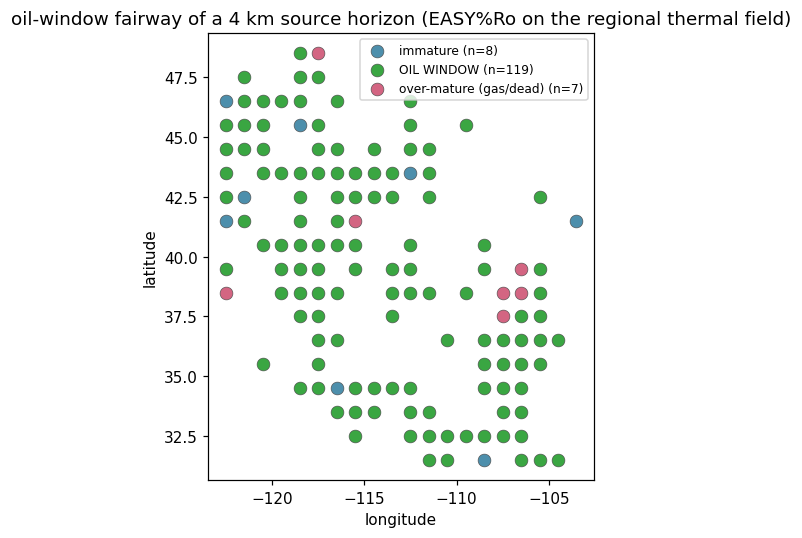

In [7]:
from mixle_pde import easy_ro
def ro_4km(q_mwm2, final=4000., ttot=60., k=2.5, surf=12., n=300):
    t = np.linspace(0,ttot,n); grad=(q_mwm2/1000.)/k*1000.
    return easy_ro(t, surf + grad*(final*t/ttot)/1000.)
# --- MODEL: maturity of a 4 km source horizon per cell -> oil-window classification ---
ro = np.array([ro_4km(q) for q in F[:,2]])
state = np.where(ro<0.6,'immature', np.where(ro<=1.35,'OIL WINDOW','over-mature (gas/dead)'))
print('oil-window cells (0.6-1.35 %%Ro at 4 km): %d of %d   | immature %d, over-mature %d'
      % (np.sum(state=='OIL WINDOW'), len(ro), np.sum(state=='immature'), np.sum(state=='over-mature (gas/dead)')))
fig, ax = plt.subplots(figsize=(6.4,5.0))
cmap = {'immature':'#4d8fac','OIL WINDOW':'#3aa642','over-mature (gas/dead)':'#d36582'}
for s,c in cmap.items():
    m = state==s; ax.scatter(F[m,0],F[m,1], c=c, s=70, label=f'{s} (n={m.sum()})', edgecolors='0.3', linewidths=0.4)
ax.set_aspect(1/np.cos(np.deg2rad(F[:,1].mean()))); ax.set(xlabel='longitude', ylabel='latitude',
       title='oil-window fairway of a 4 km source horizon (EASY%Ro on the regional thermal field)')
ax.legend(fontsize=8); plt.tight_layout(); plt.show()

## 8. The decision

What a thermal-regime study of the western US actually delivers, with its uncertainty stated honestly:

- **The pointwise heat-flow map cannot be trusted.** Cross-validation shows a smooth interpolation barely beats
  the regional mean and is grossly over-confident (§3); the variogram explains it — heat flow is **96 % nugget**
  at well spacing (§4). Any single-well "175 ± 8 °C" claim from such a map is unsupported.
- **Including the nugget is necessary but not sufficient.** It lifts 95 % coverage from 0.36 to 0.80, yet the
  per-well intervals stay over-confident at every level (§5) — a single well's heat flow is simply not
  predictable. The honest, fully-calibrated path is **aggregation**: cell means average the nugget down, and
  the central-limit theorem makes their error bars trustworthy, exposing a real regional trend (between-cell
  spread ≫ standard error).
- **Geothermal:** on that calibrated trend the fairway — cells with $P(T_{4\,\mathrm{km}}>150^\circ\mathrm{C})>0.8$
  — falls in the known high-heat-flow provinces (Basin and Range, Rio Grande rift). It is patchy, not a clean
  belt, but it is *externally validated* and *probabilistic* (§6).
- **Petroleum:** the same field, run through maturation, puts most of a 4 km source in the oil window (depth is
  the dominant control); only the hottest cells — the best geothermal ground — over-cook it, so the two
  resources conflict at the hot extreme (§7).
- **What we refuse to claim:** any well-scale temperature prediction with tight bars. The honest product is
  regional, probabilistic, and validated — which is exactly what a drilling decision should be made on.

### Limitations (the ones that bite)
The geotherm is **conductive-only**; groundwater advection — a prime suspect for the nugget — violates it, so
local temperatures can depart from the conductive prediction. The Fourier closure is partly **circular** (the
database often computes $q$ from gradient × conductivity), so it is not independent corroboration. **BHT**-based
gradients are typically biased low near the bit; a production study would use the database's corrected gradients
and uncertainties where present. The maturation uses a **schematic 4 km / 60 Myr burial**; real basin modelling
drives `easy_ro` with the basin's reconstructed burial-and-heat-flow history. Cell aggregation trades spatial
resolution for calibration — honest, but coarse.

### References
Global Heat Flow Data Assessment Group (2024), *The Global Heat Flow Database: Release 2024*, GFZ Data Services,
doi:10.5880/fidgeo.2024.014 (CC-BY 4.0); Fourier (1822), *Théorie analytique de la chaleur*; Sweeney & Burnham
(1990), *AAPG Bull.* 74, 1559 (EASY%Ro); Blackwell & Richards (2004), *SMU geothermal map of North America*;
Allen & Allen, *Basin Analysis: Principles and Applications*; Chilès & Delfiner, *Geostatistics* (the nugget).

### Exercises
1. **Advection test.** Split wells by `lithology`/basin and ask whether the nugget shrinks within
   hydrogeologically simple units — evidence for groundwater advection as a nugget source.
2. **Corrected gradients.** Where the database carries `T_grad_mean_cor`, redo §3 cross-validation with
   corrected vs raw gradients; does the nugget fall?
3. **Real burial.** Replace the schematic burial with a two-stage subsidence curve and map how the oil-window
   fairway (§7) moves — the sensitivity that matters for charge timing.
4. **Value of information.** Given the calibrated cell posteriors, where would one *new* well most reduce the
   probability of a wrong geothermal go/no-go decision? (Hook into `mixle.doe`.)